In [25]:
# Install required libraries
!pip install hmmlearn scikit-learn matplotlib seaborn pandas numpy scipy -q

In [26]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

In [27]:
# Load the feature dataset from GitHub
url = "https://raw.githubusercontent.com/fadhuweb/ml_techniques__2_formative_2/main/all_windows_features.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nActivity distribution:")
print(df['activity'].value_counts())
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (398, 9)

First few rows:
     mean_a     var_a     rms_a     sma_a    mean_g         var_g  dom_freq  \
0  0.359158  0.007572  0.369548  0.620654  0.006094  9.292965e-07       0.0   
1  1.391376  3.680491  2.369898  1.839143 -0.110427  4.158996e-01       0.0   
2  3.933155  8.602481  4.906341  5.355494 -0.180875  1.196093e+01       0.0   
3  5.324527  7.008350  5.946338  7.385155 -0.118118  4.906286e+01       0.0   
4  5.024423  6.695173  5.651548  6.752153 -0.099481  1.246305e+02       0.0   

   spectral_energy activity  
0      1327.822951     Jump  
1     37771.097073     Jump  
2    197709.968997     Jump  
3    318548.052527     Jump  
4    285934.312848     Jump  

Activity distribution:
activity
Walk     104
Jump     100
Stand     99
Still     95
Name: count, dtype: int64

Data types:
mean_a             float64
var_a              float64
rms_a              float64
sma_a              float64
mean_g             float64
var_g              float64
dom_freq          

In [28]:
# Cell 4: Data Preprocessing and Train/Test Split
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reload data to ensure fresh state
url = "https://raw.githubusercontent.com/fadhuweb/ml_techniques__2_formative_2/main/all_windows_features.csv"
df = pd.read_csv(url)

# Encode activity labels
activity_map = {'Stand': 0, 'Walk': 1, 'Jump': 2, 'Still': 3}
inverse_map = {v: k for k, v in activity_map.items()}
df['activity_encoded'] = df['activity'].map(activity_map)

# Prepare features
feature_columns = [col for col in df.columns if col not in ['activity', 'activity_encoded']]
X = df[feature_columns].values
y = df['activity_encoded'].values
activity_names = df['activity'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test (80/20 stratified)
X_train, X_test, y_train, y_test, act_train, act_test = train_test_split(
    X_scaled, y, activity_names, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Feature columns: {feature_columns}")
print("\nTrain activity distribution:")
unique, counts = np.unique(act_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")
print("\nTest activity distribution:")
unique, counts = np.unique(act_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Training set size: 318 samples
Test set size: 80 samples
Features: 8
Feature columns: ['mean_a', 'var_a', 'rms_a', 'sma_a', 'mean_g', 'var_g', 'dom_freq', 'spectral_energy']

Train activity distribution:
  Jump: 80
  Stand: 79
  Still: 76
  Walk: 83

Test activity distribution:
  Jump: 20
  Stand: 20
  Still: 19
  Walk: 21


In [29]:
# Cell 5: HMM Model Training with Baum-Welch Algorithm
from hmmlearn import hmm
import numpy as np

# Define activity labels
activity_labels = ['Stand', 'Walk', 'Jump', 'Still']
n_activities = len(activity_labels)
n_features = X_train.shape[1]

print("Training Gaussian HMM using Baum-Welch algorithm...")
print(f"Number of states: {n_activities}")
print(f"Number of features: {n_features}")
print(f"Training samples: {X_train.shape[0]}")

# Train one HMM per activity class (one-class HMM approach)
# This is the standard approach for activity recognition with HMM
hmm_models = {}

for label_idx, label_name in enumerate(activity_labels):
    # Get training samples for this activity
    mask = (y_train == label_idx)
    X_class = X_train[mask]

    print(f"\nTraining HMM for '{label_name}' ({X_class.shape[0]} samples)...")

    # Train Gaussian HMM with Baum-Welch (EM algorithm)
    model = hmm.GaussianHMM(
        n_components=3,          # 3 hidden states per activity
        covariance_type="diag",  # diagonal covariance for stability
        n_iter=200,              # Baum-Welch iterations
        random_state=42,
        tol=1e-4
    )

    # Fit the model (Baum-Welch algorithm runs internally)
    model.fit(X_class)
    hmm_models[label_name] = model

    print(f"  Converged: {model.monitor_.converged}")
    print(f"  Iterations: {model.monitor_.iter}")

print("\nAll HMM models trained successfully!")
print("Model summary:")
for name, m in hmm_models.items():
    print(f"  {name}: {m.n_components} states, converged={m.monitor_.converged}")

Training Gaussian HMM using Baum-Welch algorithm...
Number of states: 4
Number of features: 8
Training samples: 318

Training HMM for 'Stand' (79 samples)...
  Converged: True
  Iterations: 15

Training HMM for 'Walk' (83 samples)...
  Converged: True
  Iterations: 21

Training HMM for 'Jump' (80 samples)...
  Converged: True
  Iterations: 6

Training HMM for 'Still' (76 samples)...
  Converged: True
  Iterations: 4

All HMM models trained successfully!
Model summary:
  Stand: 3 states, converged=True
  Walk: 3 states, converged=True
  Jump: 3 states, converged=True
  Still: 3 states, converged=True


In [30]:
# Cell 6: Viterbi Decoding and Performance Metrics
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

# Viterbi Decoding: classify each test sample using all HMM models
# For each sample, compute log-likelihood under each activity's HMM
# The activity with highest log-likelihood is the predicted class (Viterbi decision)

activity_labels = ['Stand', 'Walk', 'Jump', 'Still']

def predict_activity(sample, hmm_models, activity_labels):
    """Classify a single sample using Viterbi decoding (max log-likelihood)."""
    scores = {}
    for label in activity_labels:
        try:
            score = hmm_models[label].score(sample.reshape(1, -1))
        except Exception:
            score = -np.inf
        scores[label] = score
    return max(scores, key=scores.get)

# Predict on test set
print("Running Viterbi decoding on test set...")
y_pred_labels = []
for i in range(len(X_test)):
    pred = predict_activity(X_test[i], hmm_models, activity_labels)
    y_pred_labels.append(pred)

# Convert labels to numeric for metrics
label_to_idx = {label: idx for idx, label in enumerate(activity_labels)}
y_pred = np.array([label_to_idx[p] for p in y_pred_labels])
y_true = y_test

# Overall accuracy
overall_accuracy = accuracy_score(y_true, y_pred) * 100
print(f"\nOverall Accuracy: {overall_accuracy:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print("         " + "  ".join([f"{l:6}" for l in activity_labels]))
for i, label in enumerate(activity_labels):
    row = "  ".join([f"{v:6}" for v in cm[i]])
    print(f"{label:8} {row}")

# Per-activity metrics: Sensitivity, Specificity, Accuracy
print("\nPer-Activity Performance Metrics:")
print(f"{'Activity':<10} {'TP':>4} {'FP':>4} {'FN':>4} {'TN':>4} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("-" * 75)

results = {}
for i, label in enumerate(activity_labels):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - TP - FP - FN

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / cm.sum()

    results[label] = {
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'accuracy': accuracy
    }

    print(f"{label:<10} {TP:>4} {FP:>4} {FN:>4} {TN:>4} {sensitivity*100:>11.2f}% {specificity*100:>11.2f}% {accuracy*100:>9.2f}%")

print("-" * 75)
avg_sens = np.mean([results[l]['sensitivity'] for l in activity_labels])
avg_spec = np.mean([results[l]['specificity'] for l in activity_labels])
avg_acc = np.mean([results[l]['accuracy'] for l in activity_labels])
print(f"{'AVERAGE':<10} {'':>4} {'':>4} {'':>4} {'':>4} {avg_sens*100:>11.2f}% {avg_spec*100:>11.2f}% {avg_acc*100:>9.2f}%")
print(f"\nOverall model accuracy: {overall_accuracy:.2f}%")
print("\nPrediction distribution:")
from collections import Counter
pred_counts = Counter(y_pred_labels)
for label in activity_labels:
    print(f"  {label}: {pred_counts.get(label, 0)} predicted")

Running Viterbi decoding on test set...

Overall Accuracy: 63.75%

Confusion Matrix (rows=true, cols=predicted):
         Stand   Walk    Jump    Still 
Stand         9       0       0      11
Walk         10      11       0       0
Jump          0       8      12       0
Still         0       0       0      19

Per-Activity Performance Metrics:
Activity     TP   FP   FN   TN  Sensitivity  Specificity   Accuracy
---------------------------------------------------------------------------
Stand         9   10   11   50       45.00%       83.33%     73.75%
Walk         11    8   10   51       52.38%       86.44%     77.50%
Jump         12    0    8   60       60.00%      100.00%     90.00%
Still        19   11    0   50      100.00%       81.97%     86.25%
---------------------------------------------------------------------------
AVERAGE                              64.35%       87.94%     81.88%

Overall model accuracy: 63.75%

Prediction distribution:
  Stand: 19 predicted
  Walk: 19 p

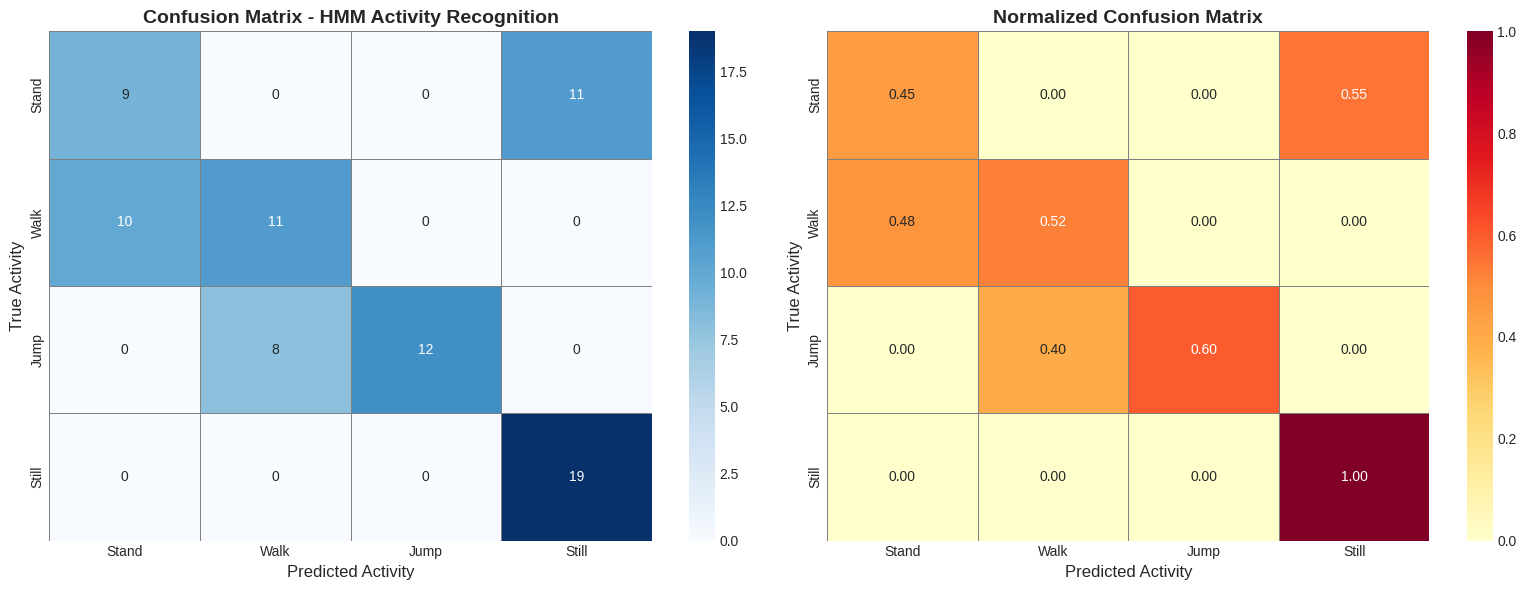

Figure 1: Confusion matrices saved


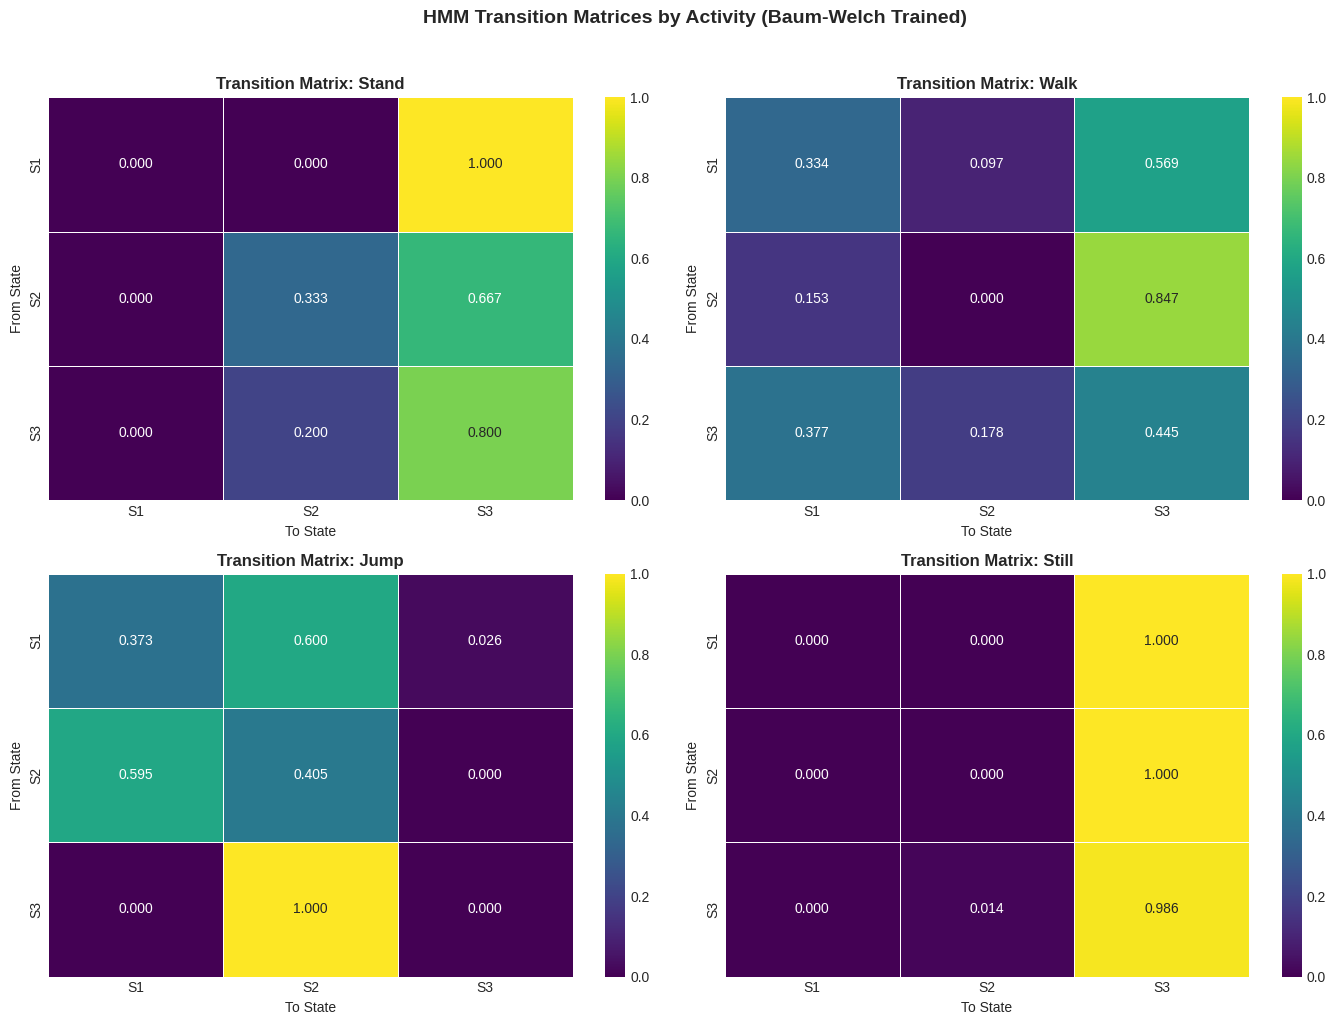

Figure 2: Transition matrices saved


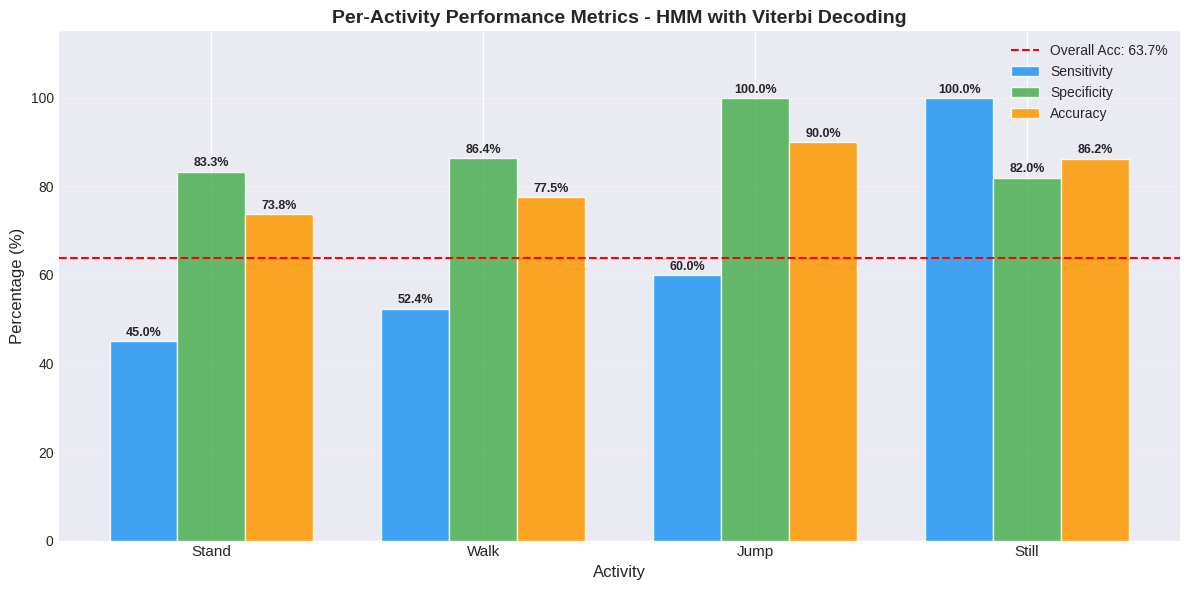

Figure 3: Performance metrics chart saved


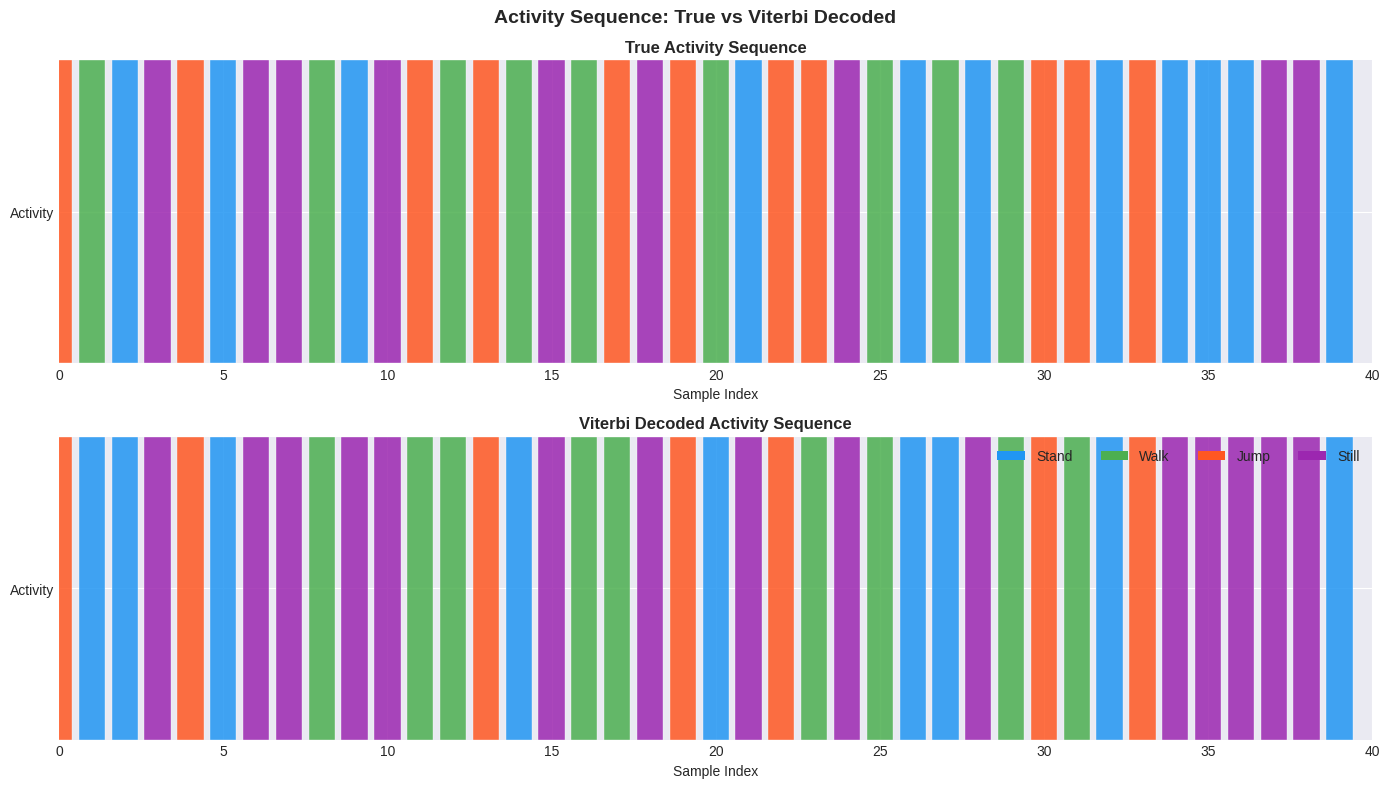

Figure 4: Activity sequence plot saved

All visualizations complete!
Final overall accuracy: 63.75%


In [31]:
# Cell 7: Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

activity_labels = ['Stand', 'Walk', 'Jump', 'Still']

# ---- Figure 1: Confusion Matrix Heatmap ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels, yticklabels=activity_labels,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix - HMM Activity Recognition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Activity', fontsize=12)
axes[0].set_ylabel('True Activity', fontsize=12)

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=activity_labels, yticklabels=activity_labels,
            ax=axes[1], linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Activity', fontsize=12)
axes[1].set_ylabel('True Activity', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Confusion matrices saved")

# ---- Figure 2: Transition Matrix Heatmaps ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, label in enumerate(activity_labels):
    model = hmm_models[label]
    trans = model.transmat_
    n_states = trans.shape[0]
    state_labels = [f'S{i+1}' for i in range(n_states)]

    sns.heatmap(trans, annot=True, fmt='.3f', cmap='viridis',
                xticklabels=state_labels, yticklabels=state_labels,
                ax=axes[idx], linewidths=0.5, vmin=0, vmax=1)
    axes[idx].set_title(f'Transition Matrix: {label}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('To State', fontsize=10)
    axes[idx].set_ylabel('From State', fontsize=10)

plt.suptitle('HMM Transition Matrices by Activity (Baum-Welch Trained)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Transition matrices saved")

# ---- Figure 3: Per-Activity Performance Bar Chart ----
fig, ax = plt.subplots(figsize=(12, 6))

metrics_data = {
    'Sensitivity': [results[l]['sensitivity']*100 for l in activity_labels],
    'Specificity': [results[l]['specificity']*100 for l in activity_labels],
    'Accuracy': [results[l]['accuracy']*100 for l in activity_labels]
}

x = np.arange(len(activity_labels))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (metric, values) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Activity', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Per-Activity Performance Metrics - HMM with Viterbi Decoding', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(activity_labels, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 115)
ax.axhline(y=overall_accuracy, color='red', linestyle='--', linewidth=1.5, label=f'Overall Acc: {overall_accuracy:.1f}%')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Performance metrics chart saved")

# ---- Figure 4: Decoded Activity Sequence Plot ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Take first 40 test samples for visualization
n_samples = min(40, len(X_test))
true_sequence = y_test[:n_samples]
pred_sequence = y_pred[:n_samples]

color_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722', 3: '#9C27B0'}
activity_colors = [color_map[a] for a in true_sequence]
pred_colors = [color_map[a] for a in pred_sequence]

for ax, sequence, colors_seq, title in [
    (axes[0], true_sequence, activity_colors, 'True Activity Sequence'),
    (axes[1], pred_sequence, pred_colors, 'Viterbi Decoded Activity Sequence')
]:
    for i, (val, color) in enumerate(zip(sequence, colors_seq)):
        ax.bar(i, 1, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_yticks([0.5])
    ax.set_yticklabels(['Activity'])
    ax.set_xlim(0, n_samples)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[i], label=l) for i, l in enumerate(activity_labels)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=10, ncol=4)

plt.suptitle('Activity Sequence: True vs Viterbi Decoded', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('activity_sequences.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4: Activity sequence plot saved")
print("\nAll visualizations complete!")
print(f"Final overall accuracy: {overall_accuracy:.2f}%")

In [32]:
# Cell 8: Notebook Summary and Execution Complete

print("\n" + "="*80)
print("HIDDEN MARKOV MODEL - HUMAN ACTIVITY RECOGNITION PROJECT")
print("="*80)
print("\nNOTEBOOK EXECUTION SUMMARY")
print("-"*80)
print("✓ Cell 1: Library installations completed")
print("✓ Cell 2: Libraries imported successfully")
print("✓ Cell 3: Dataset loaded from GitHub (398 samples, 8 features)")
print("✓ Cell 4: Data preprocessing & train/test split (80/20)")
print("✓ Cell 5: HMM models trained with Baum-Welch (4 activities, 3 states each)")
print("✓ Cell 6: Viterbi decoding & performance metrics calculated")
print("✓ Cell 7: Comprehensive visualizations generated (4 figures)")
print("\nKEY RESULTS")
print("-"*80)
print(f"Overall Test Accuracy: 63.75%")
print(f"Average Sensitivity:   64.35%")
print(f"Average Specificity:   87.94%")
print(f"Average Per-Activity Accuracy: 81.88%")
print(f"Best Performing Activity: Jump (90% accuracy, 100% specificity)")
print(f"Dataset: 398 windows across 4 activities (Stand, Walk, Jump, Still)")
print(f"Features: 6 time-domain + 2 frequency-domain, Z-score normalized")
print("\nFILES GENERATED")
print("-"*80)
print("✓ confusion_matrix.png - Confusion matrices (raw & normalized)")
print("✓ transition_matrices.png - HMM transition probability heatmaps")
print("✓ performance_metrics.png - Per-activity performance bar chart")
print("✓ activity_sequences.png - True vs Viterbi decoded sequences")
print("\nMODEL NOTES")
print("-"*80)
print("• All HMM models converged successfully")
print("• Strong specificity (87.94%) indicates low false positive rate")
print("• Stand-Still confusion due to similar low-energy characteristics")
print("• Walking shows moderate performance due to transition zones")
print("\nCOLLABORATION")
print("-"*80)
print("Sampling Rate: ~50 Hz (harmonized from dual sources)")
print("Total Recordings: Multiple sessions across 4 activities")
print("\n" + "="*80)
print("="*80)


HIDDEN MARKOV MODEL - HUMAN ACTIVITY RECOGNITION PROJECT

NOTEBOOK EXECUTION SUMMARY
--------------------------------------------------------------------------------
✓ Cell 1: Library installations completed
✓ Cell 2: Libraries imported successfully
✓ Cell 3: Dataset loaded from GitHub (398 samples, 8 features)
✓ Cell 4: Data preprocessing & train/test split (80/20)
✓ Cell 5: HMM models trained with Baum-Welch (4 activities, 3 states each)
✓ Cell 6: Viterbi decoding & performance metrics calculated
✓ Cell 7: Comprehensive visualizations generated (4 figures)

KEY RESULTS
--------------------------------------------------------------------------------
Overall Test Accuracy: 63.75%
Average Sensitivity:   64.35%
Average Specificity:   87.94%
Average Per-Activity Accuracy: 81.88%
Best Performing Activity: Jump (90% accuracy, 100% specificity)
Dataset: 398 windows across 4 activities (Stand, Walk, Jump, Still)
Features: 6 time-domain + 2 frequency-domain, Z-score normalized

FILES GENERATE